# Разбор принципов работы CNN для начинающих | PyTorch

Формально, это ноутбук для участия в учебном соревновании "[Digit Recognizer](https://www.kaggle.com/competitions/digit-recognizer)" по распознаванию рукописных цифр, но на самом деле цель этого ноутбука - объяснить начинающим принципы работы свёрточных нейронных сетей. Если вы только начинаете работать с нейронными сетями и пока не до конца понимаете, как работают свёрточные нейронные сети, прочитайте эту статью, возможно, что-то прояснится. Вы сможете изучить этот материал, даже если никогда раньше не работали с PyTorch - весь код снабжён подробными комментариями.

Tags: Beginners, NN, MLP, CNN, MNIST.

# Подготовительные операции

Код подготовки рабочего окружения:

In [1]:
notebook_name = 'kaggle.com/code/palegreendot/juggling-mnist'
print(f"Hello from {notebook_name} notebook!\n")

# Окружение Python на Kaggle уже содержит множество нужных пакетов в соответствии с образом github.com/kaggle/docker-python

# Собственно Pytorch
import torch

# Готовые блоки для построения нейронных сетей
import torch.nn as nn
import torch.nn.functional as F

# Оптимизаторы - алгоритмы, созданные для ускорения и повышения эффективности градиентного спуска
import torch.optim as optim

# Для описания принципов работы свёрточных нейронных сетей
import torch.backends.cudnn as cudnn

# Доступ к готовым наборам данных, в том числе к MNIST
from torchvision import datasets

# Преобразования. Пока нам понадобится только ToTensor()
from torchvision import transforms

# Объединение данных в пакеты (батчи), перемешивание данных при обучении, параллельная загрузка данных
from torch.utils.data import DataLoader

# NumPy. Напрямую для разработки нейронных сетей не нужен, в этом ноутбуке используется только для визуализации данных
import numpy as np

# Matplotlib. Тоже визуализация
import matplotlib.pyplot as plt

# Вспомогательный функционал
import os
import time
import datetime

# Прогресс-бар
import tqdm

import warnings
# Убираем предупреждение о необходимости соответствия аппаратного обеспечения и ПО
warnings.filterwarnings('ignore', category=UserWarning)
# Убираем предупреждение о необходимости актуализации методов
warnings.filterwarnings('ignore', category=DeprecationWarning)
# Можно использовать просто warnings.filterwarnings('ignore'), без уточнения категории,
# но это не очень хорошая практика, которая может привести к плохо уловимым ошибкам в коде

# torchviz не входит в стандартный набор пакетов Kaggle, поэтому нам нужно использовать директиву "%pip install"
%pip install torchviz
# Визуализация структуры нейросетей
from torchviz import make_dot

Hello from kaggle.com/code/palegreendot/juggling-mnist notebook!

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Это стандартная мантра Kaggle, напоминающая о некоторых ограничениях при работе на сайте
# Write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# Write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Input data files are available in the read-only "../input/" directory

# Проверяем наличие датасета MNIST
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

## Конфигурация видеокарты

Если вы работаете с данными прямо на сайте Kaggle, не забудьте в настройках подключить видеокарту.

Вычисления можно делать и на CPU, но при наличии GPU **гораздо** дальновиднее сразу настроить и начать использовать для расчётов видеокарту, иначе время ожидания результатов может неприлично вырасти. В принципе, для возни с несложными моделями на локальной машине можно использовать CPU, но, к сожалению, даже довольно мощный i9-13900K, который был у меня на момент написания статьи, и даже на относительно минималистичных датасетах вроде MNIST шевелится довольно неторопливо, хочется уже не стоять у него над душой и пойти попить кофе.

Если вы хотите использовать видеокарту на локальной машине, но `torch.cuda.is_available()` выдаёт `False`, то вам нужно:  
уточнить наличие CUDA для вашего GPU на https://developer.nvidia.com/cuda/gpus  
поставить CUDA c https://developer.nvidia.com/cuda-downloads  
установить Pytorch c поддержкой GPU https://pytorch.org/get-started/locally. Если до этого вы успели установить «обычный» Pytorch с поддержкой только CPU — удалите его.

Попробуем:

In [3]:
print(torch.cuda.is_available())

# Характеристики GPU
if torch.cuda.is_available():
    print(torch.cuda.device_count())
    print(torch.cuda.current_device())
    print(torch.cuda.device(torch.cuda.current_device()))
    print(torch.cuda.get_device_name(0))

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu'
print(f'Using {device} device')

True
1
0
NVIDIA GeForce RTX 4060
Using cuda device


## Загрузка датасетов

In [4]:
# Можете попробовать еще transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
# с использованием предварительно рассчитанных для MNIST констант (https://discuss.pytorch.org/t/normalization-in-the-mnist-example/457)
transform = transforms.ToTensor()

# Тренировочный датасет
train_data = datasets.MNIST(root='data', train=True, download=True, transform=transform)

# Тестовый датасет
test_data = datasets.MNIST(root='data', train=False, download=True, transform=transform)

# Чем больше batch_size, тем быстрее идёт процесс обучения, но тем хуже обратная связь, потому что
# реже запускается процесс обратного распространения ошибки
# shuffle=True -> данные будут подаваться в разной последовательности. Полезно для обучения
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)

# batch_size можно и побольше, на точность уже не влияет
test_loader = DataLoader(test_data, batch_size=256, shuffle=False)

print(f"Train: {len(train_data)}, Test: {len(test_data)}")

100%|██████████| 9.91M/9.91M [00:31<00:00, 316kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 188kB/s]
100%|██████████| 1.65M/1.65M [00:04<00:00, 359kB/s]
100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]

Train: 60000, Test: 10000


## Визуализация загруженных данных

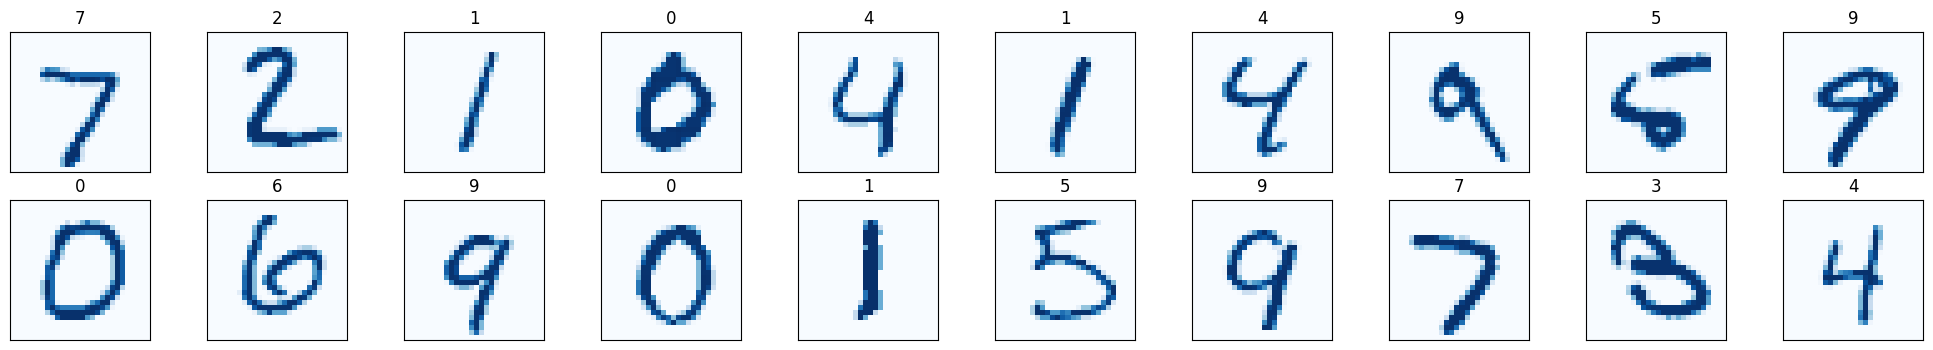

In [5]:
# Если вместо test_loader взять train_loader, картинки ниже периодически будут меняться из-за перемешивания (shuffle=True)
dataiter = iter(test_loader)
images, labels = next(dataiter)
images = images.numpy()

fig = plt.figure(figsize=(25, 4))
for idx in np.arange(20):
    ax = fig.add_subplot(2, 10, idx+1, xticks=[], yticks=[])
    # Если цвета на иллюстрациях ниже не совсем соответствуют вашему чувству прекрасного, поэкспериментируйте с cmap
    ax.imshow(np.squeeze(images[idx]), cmap='Blues')
    ax.set_title(str(labels[idx].item()))

Рассмотрим фигуристую шестёрку в деталях:

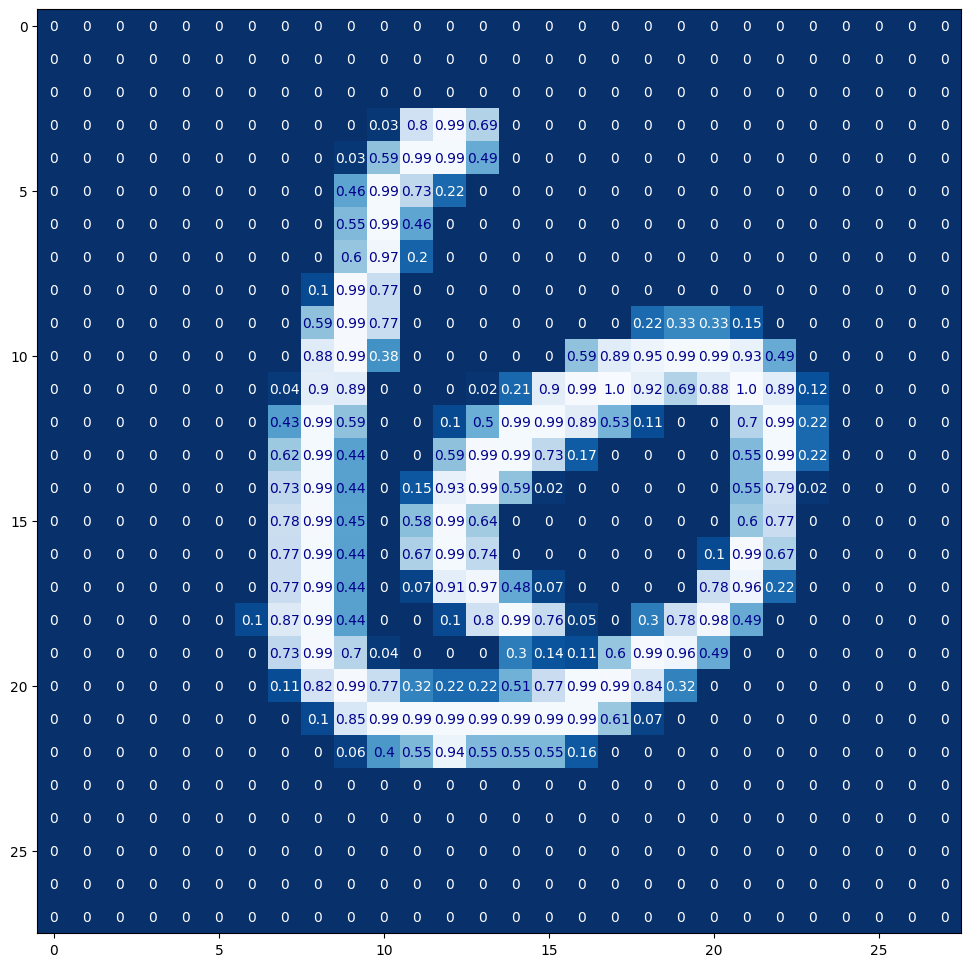

In [6]:
img = np.squeeze(images[11])

fig = plt.figure(figsize = (12,12)) 
ax = fig.add_subplot(111)
# Обратите внимание, что и здесь, и выше используется карта цветов "Blues", но прибавка "_r" инвертирует цвета. Удобно!
ax.imshow(img, cmap='Blues_r')
width, height = img.shape

threshold = img.max()/2.5

for x in range(width):
    for y in range(height):
        val = round(img[x][y], 2) if img[x][y] != 0 else 0

        # Выбираем цвет шрифта
        color = 'white' if img[x][y] < threshold else 'darkblue'

        # Отображаем ячейку
        ax.annotate(str(val), xy=(y, x), horizontalalignment='center', verticalalignment='center', color=color)

# Обзор архитектур

Как подсказывает нам [таблица](https://en.wikipedia.org/wiki/MNIST_database#Classifiers) из "Википедии" с методами решения MNIST, архитектура нашей сети должна быть или [Multilayer perceptron](https://en.wikipedia.org/wiki/Multilayer_perceptron) (MLP, многослойный перцептрон, самая простая нейронная сеть), или [Convolutional neural network](https://en.wikipedia.org/wiki/Convolutional_neural_network) (CNN, свёрточная нейронная сеть). Есть еще более развёрнутая [таблица](https://rodrigob.github.io/are_we_there_yet/build/classification_datasets_results.html), но туда стоит лезть только после более основательной подготовки.

Я хотел бы пойти чуть нестандартным путём. Давайте сначала поработаем с многослойным перцептроном, затем попробуем перейти на локально связную модель (это такой промежуточный шаг от MLP к CNN), а потом переключимся на собственно CNN. Я надеюсь, что эксперимент с локально связной нейронной сетью облегчит нам понимание принципов работы свёрточной нейронной сети.

Что ж, давайте для первого опыта возьмём самой простой вариант - перцептрон.

Архитектура для решения MNIST должна принимать на вход тензор длиной 28 * 28 = 784, а на выходе иметь тензор длиной 10 — количество классов, к которым может принадлежать входное изображение. Количество нейронов внутреннего слоя возьмём 800, как и рекомендует упомянутая чуть выше статья из "Википедии", это должно дать нам ошибку порядка 1.6 % (т. е. из 1000 изображений 984 будут распознаны правильно), что весьма недурно, учитывая то, что ошибка при ручном разборе тоже ненулевая, и обычно составляет, по разным источникам, от 98.3 до 99.8 % ("[Some cases of digits difficult to recognize, even for humans](https://www.mdpi.com/2076-3417/9/15/3169)").

Нейронная сеть у нас будет полносвязная, т. е. все нейроны предыдущего слоя соединяются со всеми нейронами следующего слоя.

# MLP

## Код MLP

In [7]:
# Нейронная сеть в рамках Pytorch должна наследоваться от nn.Module, и иметь метод forward, возвращающий архитектуру модели
class Perceptron(nn.Module):
    def __init__(self):
        super().__init__()
        #  Кроме Sequential, можно использовать ModuleList и ModuleDict, но тогда логику взаимодействия слоёв надо будет определить в методе forward()
        # Все слои внутри Sequential будут автоматически последовательно связаны друг с другом, самое то для перцептрона. Чуточку упрощает синтаксис
        self.layers = nn.Sequential(

            # Преобразует входную прямоугольную картинку в длинный одномерный массив, не затрагивая ось батчей
            nn.Flatten(),

            # Входной слой. Количество входов соответствует разрешению картинки. Linear -> "обычный" линейный слой нейронной сети
            nn.Linear(28 * 28, 800),

            # Немного нелинейной нейронной магии - функция активации. ReLU(x) = max(0, x). Без этого звена вся нейронная сеть превратится просто в метод линейной регрессии
            nn.ReLU(),

            # На каждом шаге обучения часть нейронов предыдущего слоя можно отключать для предотвращения переобучения
            nn.Dropout(p=0.3),

            # Внутренний слой
            nn.Linear(800, 800),
            nn.ReLU(),
            nn.Dropout(p=0.3),

            # Выходной слой. Количество входов равно количеству выходов предыдущего слоя, а выходов - соответствует количеству классов, на которые мы делим картинки
            nn.Linear(800, 10)
            # Здесь самое место для функции активации softmax, но он уже встроена в CrossEntropyLoss (смотри ниже)
        )
    
    def forward(self, x):
        return self.layers(x)

# Не забываем использовать GPU
model = Perceptron().to(device)

print(f"\nModel structure: {model}\n\n")

# Если хотите посмотреть, что у модели внутри, раскомментируйте код ниже
# for name, param in model.named_parameters():
#    print(f"Layer: {name} Size: {param.size()}  Values: {param[:2]} \n")


Model structure: Perceptron(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=800, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=800, out_features=800, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=800, out_features=10, bias=True)
  )
)




## Визуализация модели

Визуализация модели при помощи [PyTorchViz](https://github.com/szagoruyko/pytorchviz).

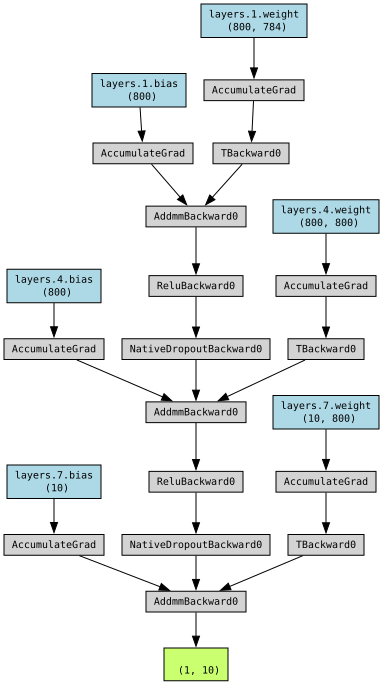

In [8]:
# Закидываем в нашу нейронную сеть тестовый тензор, чтобы PyTorchViz мог проанализировать её внутреннее устройство.
x = torch.randn(1, 28 * 28).to(device)

make_dot(model(x), params=dict(model.named_parameters()))

## Настройка MLP

Если вы раскомментируете строку "print(f"Layer: {name} Size: {param.size()..." в коде выше, то увидите, что сразу после инициализации слои уже наполнены какими-то [коэффициентами](https://en.wikipedia.org/wiki/Weight_initialization). Почему не нули? Разъяснение здесь - "[An Explanation of Xavier Initialization](https://andyljones.tumblr.com/post/110998971763/an-explanation-of-xavier-initialization)", а конкретный код - [вот здесь](https://github.com/pytorch/pytorch/blob/099a6d5e083d78e04437a22e7cf963c4e0a1fa18/torch/nn/modules/linear.py#L48-L52) (поищите на странице `def reset_parameters`, если код после какого-то коммита будет переформатирован).

Выбираем функцию потерь:

In [9]:
criterion = nn.CrossEntropyLoss()

Выбираем функцию оптимизации:

In [10]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)

## Тренировка MLP

In [11]:
# Количество эпох
n_epochs = 32

# Пустой список для будущего графика
train_loss_curve = []

def model_train():
    # Включение специфических слоёв (Dropout, BatchNorm), используемых только во время обучения. Даже если таких слои отсутствуют,
    # всё равно используйте model.train(), чтобы потом, при их добавлении, не искать ошибки
    model.train()

    # Замеряем продолжительность обучения
    start = time.time()

    # Создаем прогресс-бар
    pbar = tqdm.tqdm(range(1, n_epochs + 1))

    for epoch in pbar:
        train_loss = 0.0  # Мониторим ошибку

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # Очистка старых градиентов. Можно работать и с накоплением градиентов, но этот трюк не для данной (стандартной) ситуации
            optimizer.zero_grad()

            # Прямой проход, модель обсчитывает данные с использованием текущих параметров
            outputs = model(images)

            # Рассчитываем ошибку
            loss = criterion(outputs, labels)

            # Вычисление новых градиентов. Под капотом: обратное распространение ошибки = вычисление частных производных по каждому параметру
            loss.backward()

            # Обновление всех весов модели
            optimizer.step()
            train_loss += loss.item() * images.size(0)

        # Считаем среднюю ошибку за эпоху
        train_loss = train_loss/len(train_loader.dataset)
        train_loss_curve.append(train_loss)
        pbar.set_description(f'Epoch {epoch}  \tTraining Loss: {train_loss:.4f}')

    end = time.time()
    print(f"\nElapsed time: {str(datetime.timedelta(seconds=round(end-start)))}")

model_train()

Epoch 18  	Training Loss: 0.0409:  56%|█████▋    | 18/32 [02:12<01:42,  7.35s/it]


KeyboardInterrupt: 

Разумеется, вы можете заложить в код условие остановки тренировки при достижении желаемого результата.

## График ошибки MLP

Посмотрим, как ведёт себя ошибка:

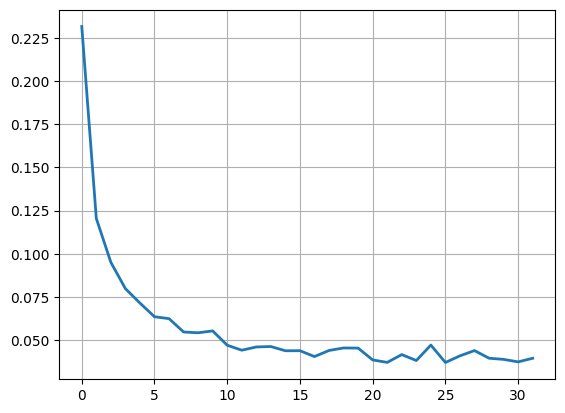

In [ ]:
plt.plot(train_loss_curve, linewidth=2)
plt.grid(True)
plt.show()

Оцените скачок точности уже после первой эпохи - с 10 % (классификатор с 10 выходами со случайными весами внутри -> точность = 100 % / 10) до ~80 %!

Обратите внимание, если ранее в ответ на `print(f'Using {device} device')` вы увидели `Using cuda device`, то загрузка CPU должна быть довольно небольшой, а GPU/CUDA - достаточно серьёзной. В случае, если модель всё-таки не «зацепилась» за GPU (у меня такое бывало в процессе учёбы из-за мелких помарок в коде), вы увидите серьёзную загрузку CPU. То, что Pytorch «видит» видеокарту и CUDA, еще не значит, что он будет использовать их по умолчанию; нужно уместно использовать `.to(device)`, иначе можно получить низкую загрузку GPU, сильно выросшее время расчёта модели и даже ошибки типа `RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu`.

## Тестирование MLP

Тестирование модели обязательно проводится на проверочных данных, отличных от тренировочных. Вообще, проверочные данные всё-таки опосредованно проникают в гиперпараметры вашей модели (количество, размер и тип слоёв, размер батча, коэффициенты регуляризации и т. д. - в общем, всё то, что определяется еще до начала обучения), потому что каждый раз, получая не удовлетворяющий вас результат, вы начинаете подкручивать гиперпараметры, тем самым невольно включая проверочные данные в архитектуру модели. Поэтому для чистоты эксперимента необходимо разбивать всю выборку на тестовые, проверочные и **контрольные** данные; контрольные данные держатся от модели "в секрете", на них проводится самая последняя, финальная проверка. Но конкретно сейчас мы так заморачиваться не будем ради большей прозрачности процесса.

In [ ]:
def model_eval():
    # Выключение слоёв Dropout и BatchNorm, используемых только во время обучения. Также как и случае с model.train(), всегда переключайте модель в eval()
    model.eval()

    correct = 0
    total = 0
    # Отключаем возможность обратного прохода и вычисления градиентов, экономя память и процессорное время
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f'Accuracy: {100 * correct / total:.2f}%')

model_eval()

Accuracy: 98.22%


# Запись и чтение моделей

Теперь, когда модель обучена и проверена, можно сохранить её на диск. Пример у нас простенький, обучение занимает не очень много времени, но это, надеюсь, ненадолго - чем с более сложными моделями вы будете работать, тем больше времени, аппаратных ресурсов и душевных сил будет уходить на их обучение и дообучение, так что лучше сразу научиться модели где-нибудь хранить.

Давайте прикинем размер получившейся модели. Это будет полезно в том числе для дальнейшего сравнения с CNN.

Количество весов в одном линейном полносвязном слое = количество входов * количество выходов + количество выходов (с учётом bias).

(784 * 800 + 800) + (800 * 800 + 800) + (800 * 10 + 10) = 1276810 весов.

Проверим:

In [ ]:
params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {params}")

Parameters: 1276810


Веса хранятся в формате float32, итого 1276810 * 4 байта = 5107240 ≈ 4.87 МиБ

Сохраним модель:

In [ ]:
# Сохранение только весов модели
torch.save(model.state_dict(), 'model_weights.pth')

# Можно сохранить модель целиком, и структуру, и веса, но так делать не рекомендуется
# torch.save(model, 'full_model.pth')

Размер получившихся файлов тоже ≈ 4.87 МиБ, всего на несколько КиБ больше за счёт служебных данных.

Считываем веса модели:

In [ ]:
model.load_state_dict(torch.load('model_weights.pth'))

<All keys matched successfully>

Итого по MLP для распознавания MNIST:  
• полносвязная модель;  
• архитектура 784-800-10;  
• точность 98.3 %;  
• размер 4.87 МиБ;  
• время тренировки 2 минуты 47 секунды.

# Визуализация модели 2

После сохранения модели можно применить еще одно достаточно популярное средство визуализации - [Netron](https://github.com/lutzroeder/netron). Для полной модели картинка будет примерно вот такая: full_model.pth.png

# Локально связная сеть

Перед тем, как перейти к собственно свёрточной сети, давайте попробуем сделать один шаг, который, хотя и не будет особо эффективным с точки зрения точности решения поставленной задачи, но зато несколько углубит наше понимание свёрточных сетей. Ну в самом деле, прямо сейчас мы можем просто подключить встроенные в Pytorch свёрточные слои, причем код будет выглядеть примерно также, как и предыдущая модель, и даст нам знания по использованию встроенного функционала, то есть примерно ничего. Давайте сами напишем аналог свёрточной сети, тогда полученный код сможет дать нам несколько более глубокое понимание происходящего, свёртка перестанет быть магией, а превратится просто в инструмент.

Давайте порассуждаем.

Количество весов в первом слое нейронов полносвязной сети равно 784 * 800 (без учёта bias), итого 627200. В тоже время, для распознавания картинок имеет смысл в первую очередь анализировать элементы, расположенные в непосредственной близости. Например, для входного изображения размером 28 х 28 пикселей можно попробовать анализировать "квадратики" размером, скажем, 2 х 2, 3 х 3 или 4 х 4 пикселя, пытаясь вычленить информацию, соответствующую не просто отдельным пикселям, а их группам.

Это называется **локально связанный слой**. Представьте, что к первому нейрону первого скрытого слоя идут связи не от всех 784 входных нейронов, а только от 9, от квадратика 3 x 3, расположенного в левом верхнем углу изображения. Далее, ко второму скрытому нейрону идут 9 связей от квадратика 3 x 3, смещенного на один пиксель вправо от начала картинки, и так далее.

Локально связный слой не входит в стандартную поставку Pytorch, но, к счастью, в людях иногда просыпается тяга к экспериментам, так что реализацию локально связного слоя в Сети найти всё-таки можно.

## Код локально связной сети

In [ ]:
# Класс локально связного слоя. Реализация такого слоя в Pytorch отсутствует, поэтому реализуем логику самостоятельно
class LocallyConnected2d(nn.Module):
    def __init__(self, in_channels, out_channels, input_height, input_width, kernel=3, stride=1):
        super().__init__()
        # Размер ядра
        self.kernel = kernel
        
        # Шаг смещения
        self.stride = stride

        # Здесь еще должен быть padding для возможности сохранения размера изображения, как в "настоящих" CNN, но для учебного примера сойдёт
        self.out_height = (input_height - kernel) // stride + 1
        self.out_width = (input_width - kernel) // stride + 1

        # Инициализация Кайминга. Можно использовать и более понятный nn.init.kaiming_normal_,
        # но для нашей нестандартной архитектуры понадобится дополнительный код
        self.weight = nn.Parameter(torch.randn(self.out_height, self.out_width, out_channels, in_channels * kernel ** 2) * (2.0 / (in_channels * kernel ** 2)) ** 0.5)

        # bias должен инициализироваться нулями
        self.bias = nn.Parameter(torch.zeros(self.out_height, self.out_width, out_channels))

        # Если код ниже не очень понятен - ничего страшного, это просто концепция,
        # призванная продемонстрировать, что за каждым методом PyTorch лежит конкретная математика,
        # и что иногда можно реализовать нужный вам функционал в обход стандартных путей
    def forward(self, x):
        # Скользим окном kernel × kernel по высоте (ось 2) и ширине (ось 3) с заданным шагом
        # Получаем все патчи — вырезанные фрагменты изображения, к которым будут применяться веса
        patches = x.unfold(2, self.kernel, self.stride).unfold(3, self.kernel, self.stride)

        # Меняем порядок осей: перемещаем пространственные координаты (h, w) на второе и третье место,
        # а каналы и пиксели патча — в конец. contiguous() перекладывает данные в памяти под новый порядок
        patches = patches.permute(0, 2, 3, 1, 4, 5).contiguous()

        # Сплющиваем каналы и пиксели каждого патча в один длинный вектор
        # Теперь каждый патч — это просто список чисел, готовый к умножению на веса
        patches = patches.view(x.size(0), self.out_height, self.out_width, -1)

        # Для каждой позиции (h, w) перемножаем её патч с её собственными весами — не общими для всей карты
        # Именно здесь локальная связность: у каждой позиции свой независимый набор весов
        out = torch.einsum('bhwi,hwoi->bhwo', patches, self.weight) + self.bias

        # Возвращаем каналы на второе место — приводим тензор к стандартному формату (батч, каналы, высота, ширина)
        # Это нужно, чтобы следующий слой получил данные в привычном для Pytorch порядке осей
        return out.permute(0, 3, 1, 2)

class LocallyConnectedNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.lc1 = LocallyConnected2d(1, 16, 28, 28)  # -> 16x26x26
        self.lc2 = LocallyConnected2d(16, 32, 13, 13)  # -> 32x11x11
        self.fc1 = nn.Linear(32 * 5 * 5, 128)  #  "Нормальный" полносвязный слой для классификации изображений 800 -> 128
        self.fc2 = nn.Linear(128, 10)  # "Нормальный" полносвязный выходной слой 128 -> 10

    def forward(self, x):       # x: 1x28x28
        x = self.lc1(x)         # Локально связный слой, патчи 3×3, 16 выходных каналов
        x = F.relu(x)
        x = F.max_pool2d(x, 2)  # Берём максимум в каждом окне 2×2, размер уменьшается вдвое. max_pool2d сами писать не будем, это штатный слой в Pytorch

        # Здесь может иметь место потеря пикселей при нечётных размерах изображения (из-за деления в коде LocallyConnected2d), но для MNIST всё работает

        x = self.lc2(x)         # Второй локально связный слой, 32 выходных канала
        x = F.relu(x)
        x = F.max_pool2d(x, 2)  # Снова уменьшаем размер вдвое (11//2 = 5)

        x = x.flatten(1)        # Разворачиваем 32×5×5 в плоский тензор длиной 800, объединяя все оси тензора, кроме нулевой
        x = self.fc1(x)         # 128 полносвязных нейронов, 800 → 128
        x = F.relu(x)

        x = self.fc2(x)         # Полносвязный слой 128 → 10
        return x                # Возвращаем логиты (Softmax будет применена позже, при расчёте функции потерь)

In [ ]:
model = LocallyConnectedNet().to(device)

print(f"\nModel structure: {model}\n\n")
# for name, param in model.named_parameters():
#    print(f"Layer: {name} Size: {param.size()}  Values: {param[:2]} \n")


Model structure: LocallyConnectedNet(
  (lc1): LocallyConnected2d()
  (lc2): LocallyConnected2d()
  (fc1): Linear(in_features=800, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)




## Тренировка локально связной сети

Код тренировки и код измерения точности для локально связной модели ничем не отличается от кода полносвязной модели, просто переопределяем функцию оптимизации и переиспользуем основной код:

In [ ]:
# На этом этапе, кстати, можно подключить разные оптимизаторы для разных слоёв модели или "заморозить" часть слоёв
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

model_train()

Epoch 32  	Training Loss: 0.0078: 100%|██████████| 32/32 [03:36<00:00,  6.75s/it]


Elapsed time: 0:03:36


## Сравнение графиков ошибок

На общем графике ошибок я подсветил новые данные желтым прямоугольником:

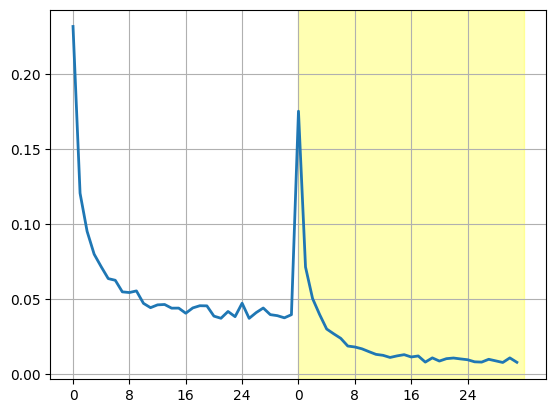

In [ ]:
# Немного колдовства, чтобы правая половина графика тоже наглядно отсчитывалась от нуля
x_positions = list(range(0, n_epochs)) + list(range(n_epochs, 2 * n_epochs))

plt.plot(x_positions, train_loss_curve, linewidth=2)

x_ticks = list(range(0, 2 * n_epochs, n_epochs // 4))
x_labels = [str(i % n_epochs) for i in x_ticks]

plt.xticks(x_ticks, x_labels)

# Подсветка второй половины графика
plt.axvspan(n_epochs, 2 * n_epochs, color='yellow', alpha=0.3)

plt.grid(True)
plt.show()

Я намеренно не почистил список train_loss_curve от предыдущих значений, полученных в ходе тренировки полносвязной сети. Обратите внимание, как снижается ошибка локально связной сети (график подсвечен жёлтым) по сравнению с полносвязной сетью.

Измеряем точность модели:

In [ ]:
model_eval()

Accuracy: 98.67%


Наша самописная архитектура довольно неэффективно использует ресурсы GPU, поэтому время обучения вряд ли уменьшится по сравнению с MLP, а вот количество параметров существенно снизилось:

In [ ]:
params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {params}")

Parameters: 773418


И это при равной, а то и чуть лучшей точности.

# CNN, свёрточная нейронная сеть

## Код CNN

Вот код свёрточной сети для решения MNIST:

In [ ]:
class CNN_Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(32 * 5 * 5, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.net(x)

Благодаря предыдущему разбору локально связной сети принцип работы слоя `nn.Conv2d` становится несколько более понятен.

In [ ]:
model = CNN_Net().to(device)

print(f"\nModel structure: {model}\n\n")
# for name, param in model.named_parameters():
#    print(f"Layer: {name} Size: {param.size()}  Values: {param[:2]} \n")


Model structure: CNN_Net(
  (net): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=800, out_features=128, bias=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=10, bias=True)
  )
)




## Тренировка CNN

И снова переиспользуем код тренировки:

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Эту строку мы обсудим чуть ниже
cudnn.benchmark = True

model_train()

Epoch 32  	Training Loss: 0.0016: 100%|██████████| 32/32 [03:03<00:00,  5.73s/it]


Elapsed time: 0:03:03


## Сравнение графиков ошибок трёх моделей

Окончательный график, теперь желтым подсвечена ошибка, выданная CNN.

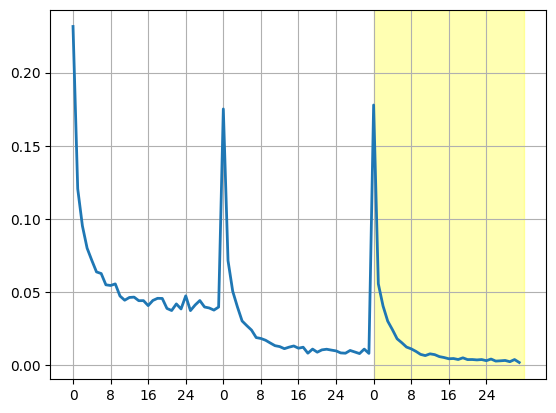

In [ ]:
x_positions = list(range(0, n_epochs)) + list(range(n_epochs, 3 * n_epochs))

plt.plot(x_positions, train_loss_curve, linewidth=2)

x_ticks = list(range(0, 3 * n_epochs, n_epochs // 4))
x_labels = [str(i % n_epochs) for i in x_ticks]

plt.xticks(x_ticks, x_labels)

# Подсветка последней трети графика
plt.axvspan(2 * n_epochs, 3 * n_epochs, color='yellow', alpha=0.3)

plt.grid(True)
plt.show()

Точность:

In [ ]:
model_eval()

Accuracy: 98.89%


In [ ]:
params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {params}")

Parameters: 108618


# Тонкости реализации CNN

Так, OK, мы видим, что весь код рабочий, и ошибка последовательно уменьшается при движении в направлении MPL -> локально связные слои -> CNN. Теперь давайте еще раз пройдемся по принципам работы свёрточной нейронной сети, чтобы закрепить понимание.

Рассуждая о свёрточных нейронных сетях, для наглядности часто употребляют упрощение, которое уже стало общим местом и зачастую употребляется без подтекста "метафоры", чего нам всё-таки следует избегать.

Это упрощение - «маска пробегает по входному изображению». На самом деле, никакая маска никуда не бегает. Эта всего лишь визуальная концепция, призванная пояснить базовые принципы свёртки. Вот такой код вы на практике нигде никогда не увидите, потому что результат, хотя и будет верным, но окажется катастрофически медленным:
```
for b in range(B):                           # Батчи
    for co in range(C_out):                  # Выходные каналы
        for i in range(H_out):               # Высота выхода
            for j in range(W_out):           # Ширина выхода
                for ci in range(C_in):       # Входные каналы
                    for ki in range(KH):     # Высота ядра
                        for kj in range(KW): # Ширина ядра
                            output[b, co, i, j] += (input[b, ci, i * stride + ki, j * stride + kj] * kernel[co, ci, ki, kj])
```

«Маска пробегает» достаточно корректно описывает то, ЧТО вычисляется, но совершенно не отражает, КАК происходит реальный процесс вычисления. Реальная свёртка — это, в простейшем случае, по сути хитрая переупаковка данных и последующее одно большое матричное умножение, позволяющее корректно задействовать параллелизацию в GPU.

Существует несколько основных подходов к быстрой реализации свёртки, а в Pytorch, в свою очередь, встроен механизм выбора наиболее быстрого метода, который опирается на параметры модели и доступные аппаратные ресурсы. Для того, чтобы Pytorch запомнил результат выбора и не повторял эту процедуру (при выборе приходится нести некоторые накладные расходы, т. к. это не просто блок инструкций "if-else", а скорее нагрузочное тестирование), можно использовать ключ, упомянутый ранее:

In [ ]:
cudnn.benchmark = True

Какие же варианты рассматривает Pytorch?

Самый популярный метод называется im2col + GEMM. Он извлекает из изображения все патчи (прямоугольные фрагменты, по размеру совпадающие с ядром), а потом "раскатывает" набор патчей в матрицу, количество строк в которой равно длине патча (например, если ядро имеет размер три на три и три входных канала, то каждый столбец будет содержать двадцать семь чисел), а количество столбцов - количеству патчей. Ядро свёртки, в свою очередь, разворачивается в матрицу из одной строки, после чего матрицы перемножаются.

Давайте рассмотри пример для простенького изображения размером 4 * 4 и ядра размером 2 * 2.

Входное изображение 4 * 4:
```
a  b  c  d
e  f  g  h
i  j  k  l
m  n  o  p
```

Ядро 2 * 2:
```
w1  w2
w3  w4
```

Преобразовываем входное изображение в матрицу `М1` вида (эту ступенька алгоритма называется im2col, image to column):
```
a  b  c  e  f  g  i  j  k
b  c  d  f  g  h  j  k  l
e  f  g  i  j  k  m  n  o
f  g  h  j  k  l  n  o  p
```

Обратите внимание на повторы в развёрнутой матрице патчей. Это избыточность по памяти, которой платят за возможность свести свёртку к одному большому и быстрому матричному умножению.

Ядро, в свою очередь, разворачиваем в строку `М2`:
```
w1  w2  w3  w4
```

Перемножаем (здесь применяется GEMM, General Matrix Multiply):
```
М1 * М2 = строка (1 * 9)
```

Каждый элемент результата — скалярное произведение строки ядра на соответствующий столбец. Например, первый элемент равен w1 * a + w2 * b + w3 * e + w4 * f.

Фишка в том, что GEMM - это супер-пупер быстрый алгоритм, выжимающий всё до капли из аппаратных возможностей вашего компьютера. Ассемблер, оптимальное использование процессорного кэша, SIMD-инструкции, использование аппаратных возможностей GPU, параллелизм GPU - всё это уже внесено в GEMM, тщательно оптимизировано, и заточено только на одно - скорость. Как только вам удалось свести задачу к умножению матриц - всё, просто активируете термоядерную бензопилу GEMM и отходите в сторону, чтобы вас не забрызгало.

Тут, мне кажется, имеется довольно-таки существенное расхождение между теорией и практикой. Силясь накачать математическую мышцу и читая, скажем, "Математику в машинном обучении" Дайзенрота, Фейзала и Она, начинающий датасайентист начинает всерьёз прикидывать, как он будет решать системы линейных уравнений - при помощи ли стационарных итерационных методов, таких как методы Ричардсона, Якоби, Гаусса — Зейделя, или же при помощи методов подпространств Крылова, таких как сопряженные градиенты, обобщенные минимальные невязки или бисопряженные градиенты? Наконец, при попытке разобраться в методе последовательной верхней релаксации датасайентиста наконец настигает спасительный обморок и он может немного отдохнуть. Правильный ответ для 95 % процентов практических задач, особенно для позиций Junior и Middle - никак. Само собой, не совсем всегда никак, но если в рабочее время вам на полном серьёзе приходится подбирать алгоритм решения системы линейных уравнений, копая глубже стандартных `np.linalg.solve`, `scipy.sparse.linalg` или `np.linalg.cholesky`, то ваша должность, предположительно, будет называться не просто "Machine Learning Engineer".

Ну и возвращаясь к нашим практическим занятиям - полученную строку из 9 чисел переформатируем обратно в матрицу 3×3 — это и есть выходная карта признаков.

Кроме сочетания im2col + GEMM, есть еще более экзотические методы свёртки, которые выглядят более тяжеловесными, но с успехом применяются Pytorch на определённых видах данных. Например, алгоритм БПФ (быстрого преобразования Фурье), переводящий вычисления в частотную область и дающий выигрыш по скорости при больших размерах ядра или алгоритм Винограда, оптимизированный для размера ядра 3 * 3 и также, как и БПФ, переводящий матрицы в специальный базис, в котором свёртка заменяется поэлементным умножением.

# Заключение

На этом пока всё, надеюсь, это руководство было для вас полезным, и теперь вы чуть лучше понимаете принципы работы свёрточных нейронных сетей.

Если вам более комфортно работать с GitHub, то вот адрес этой статьи там - [Разбор принципов работы CNN для начинающих | PyTorch](https://github.com/amaargiru/kaggle-notebooks/blob/main/01-PyTorch-MLP-CNN-MNIST-for-beginners/01-PyTorch-MLP-CNN-MNIST-for-beginners.ipynb)

Помните, что главный инструмент обучения - это код внутри ноутбуков. Что-то непонятно? Нашли ошибку? Есть что добавить? Обязательно скопируйте этот ноутбук и проверьте свои предположения, модифицировав и запустив код.